<div style="display:inline-block;vertical-align:top;">
<img src= "https://urosario.edu.co/static/getmedia/4b482c72-87c2-49a5-8e81-14312e6270f0/logo-Medicina_Mesa-de-trabajo-1" width=500>


</div>

# **Seminario Tendencias de la Inteligencia Artificial en Salud**
## ***Machine Learning* (ML) para Aplicaciones en Salud**

##**Aprendizaje Supervisado - Regresión**

Alvaro David Orjuela Cañón

alvaro.orjuela@urosario.edu.co

<img src="https://images.shiksha.com/mediadata/ugcDocuments/images/wordpressImages/2022_04_image-63.jpg" width=500>

# **Aprendizaje Supervisado**

Necesita datos entrada-salida para que el modelo aprenda que para cada vector de entrada hay una salida que debe aprender.

Realizaremos dos ejemplos:

*  **Parte 1: Clasificación** Necesita las **etiquetas** o clases que debe aprender

*  **<FONT SIZE=3 Color="red">Parte 2: Regresión:</FONT>** Necesita **los valores** que debe aprender





## **<center><FONT SIZE=5 Color="red">Regresión 1</FONT></center>**

### **Conjunto de Datos**

Extraemos la base de datos **Bogotá: Apartamentos** de **[Kaggle](https://www.kaggle.com/datasets/pablobravo73/real-estate-bogota)**

<br>
<center><img src="https://i.ibb.co/6nfN4Z0/bogota-apartments02.png" alt="centered image" width="700" height="200"></center>
<br>

donde (*algunas variables*),

<table>
<tr>
    <th>Columna</th>
    <th>Descripción</th>
</tr>
<tr></tr>
  <td>Tipo</td>
 	<td>El tipo de propiedad, que puede ser apartamento, casa, oficina, local, lote, bodega, etc.</td>
<tr>
  <td>Descripción</td>
  <td>Una breve descripción del inmueble.</td>
</tr>
<tr>
  <td>Habitaciones</td>
  <td>La cantidad de habitaciones en el inmueble.</td>
</tr>
<tr>
  <td>Baños</td>
  <td>La cantidad de baños en el inmueble.</td>
</tr>
<tr>
  <td>Área</td>
  <td>El tamaño del área en metros cuadrados del inmueble.</td>
</tr>
<tr>
  <td>Barrio</td>
  <td>El nombre del barrio donde se encuentra el inmueble.</td>
</tr>
<tr>
  <td>UPZ</td>
  <td>La Unidad de Planeamiento Zonal donde se encuentra el inmueble.</td>
</tr>
<tr>
  <td>Valor</td>
  <td>El valor del inmueble en pesos colombianos (COP).</td>
</tr>
</table>

***Problema***: Estimar el valor del apartamento, a partir de otras variables (Habitaciones, Baños y Área) mencionadas (<Font color=red>Regresión</Font>).

**Importamos Librerías:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Obtenemos los datos de [Kaggle](https://www.kaggle.com/datasets/pablobravo73/real-estate-bogota)**

In [ ]:
!curl -L -o /content/real-estate-bogota.zip\
  https://www.kaggle.com/api/v1/datasets/download/pablobravo73/real-estate-bogota

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 92994  100 92994    0     0   154k      0 --:--:-- --:--:-- --:--:--  154k


In [ ]:
!unzip /content/real-estate-bogota.zip

Archive:  /content/real-estate-bogota.zip
  inflating: inmuebles_bogota.csv    


***One Hot Encoding***

```Castilla = [0 1 0 0 0 0 0 0 .... 0]```

In [ ]:
dataset = pd.read_csv("/content/inmuebles_bogota.csv")
dataset

,Tipo,Descripcion,Habitaciones,Baños,Área,Barrio,UPZ,Valor
0,Apartamento,Apartamento en venta en Zona Noroccidental,3,2,70,Zona Noroccidental,CHAPINERO: Pardo Rubio + Chapinero,$ 360.000.000
1,Casa,Casa en venta en Castilla,4,3,170,Castilla,KENNEDY: Castilla + Bavaria,$ 670.000.000
2,Apartamento,Apartamento en venta en Chico Reservado,3,3,144,Chico Reservado,CHAPINERO: Chicó Lago + El Refugio,$ 1.120.000.000
3,Apartamento,Apartamento en venta en Usaquén,3,2,154,Usaquén,Usaquén,$ 890.000.000
4,Apartamento,Apartamento en venta en Bella Suiza,2,3,128,Bella Suiza,USAQUÉN: Country Club + Santa Bárbara,$ 970.000.000
...,...,...,...,...,...,...,...,...
9515,Apartamento,Apartamento en venta en Kennedy,3,2,70,Kennedy,Kennedy Central,$ 290.000.000
9516,Apartamento,Apartamento en venta en Parque Central Bavaria,2,2,100,Parque Central Bavaria,SANTA FE: Las Nieves + Sagrado Corazón,$ 670.000.000
9517,Local,Local en venta en Restrepo,8,6,383,Restrepo,Restrepo,$ 900.000.000
9518,Casa,Casa en venta en Engativa,3,2,183,Engativa,Engativá,$ 335.000.000


**Creamos un dataset con solo apartamentos**

In [ ]:
dataset1 = dataset[dataset['Tipo']=='Apartamento']
dataset1.shape

(7327, 8)

**Observamos las variables <font color=red> Barrio </font>  y <font color=red>UPZ </font>**

In [ ]:
dataset1['Barrio'].unique().shape, dataset1['Barrio'].unique()

((136,),
 array(['Zona Noroccidental', 'Chico Reservado', 'Usaquén', 'Bella Suiza',
        'El Chicó', 'Tintala', 'Kennedy', 'Nicolas De Federman',
        'La Calleja', 'Mazuren', 'Suba', 'Barrios Unidos', 'Engativa',
        'Fontibón', 'Villa Alsacia', 'Palermo', 'La Candelaria',
        'El Contador', 'El Batán', 'Santa Barbara', 'Mirandela ',
        'Castilla', 'Cedritos', 'Colina Campestre', 'Hayuelos',
        'Ciudad Salitre', 'Quinta Paredes', 'Candelaria La Nueva',
        'Chico Norte', 'Normandia', 'Ciudad Bolívar', 'Bosa',
        'Rafael Uribe Uribe', 'Las Villas', 'San Patricio', 'Barrancas',
        'Teusaquillo', 'Puente Aranda', 'Chapinero', 'Usme', 'Madelena',
        'El Plan', 'Nueva Zelandia', 'Santa Paula', 'Villemar', 'Santa Fe',
        'Antonio Nariño', 'Los Rosales', 'Chapinero Central', 'La Uribe',
        'Los Mártires', 'Bogotá D.C', 'Marly', 'San Cristobal',
        'Gran America', 'Gran Granada', 'La Salle', 'Portales Del Norte',
        'Cantagallo', 

In [ ]:
dataset1['UPZ'].unique().shape, dataset1['UPZ'].unique()

((60,),
 array(['CHAPINERO: Pardo Rubio + Chapinero',
        'CHAPINERO: Chicó Lago + El Refugio', 'Usaquén',
        'USAQUÉN: Country Club + Santa Bárbara', 'Tintala',
        'Kennedy Central', 'Teusaquillo', 'El Prado', 'Suba', 'Los Andes',
        'Engativá', 'Fontibón', 'KENNEDY: Castilla + Bavaria', 'Galerías',
        'La Candelaria', 'Los Cedros', 'La Alhambra',
        'SUBA: La Academia + Guaymaral + San José de Bavaria', 'Niza',
        'Modelia', 'Ciudad Salitre Oriental',
        'ENGATIVÁ: Santa Cecilia + Jardín  Botánico',
        'CIUDAD BOLÍVAR: Monteblanco + El Tesoro + El Mochuelo',
        'Bosa Central', 'Los Alcázares', 'San Cristóbal Norte',
        'PUENTE ARANDA: Zona Industrial + Puente Aranda',
        'USME: Alfonso López + Ciudad Usme', 'Arborizadora', 'El Rincón',
        'SANTA FE: Las Nieves + Sagrado Corazón', 'Restrepo',
        'Localidad Chapinero resto', 'La Sabana',
        'Ciudad Salitre Occidental', 'Sosiego', 'Quinta Paredes',
        'Garcés

**Creamos un ```DataFrame``` con solo las variables:**

* Habitaciones
* Baños
* Área

In [ ]:
datasetAptos = dataset1.iloc[:,2:5]
datasetAptos

,Habitaciones,Baños,Área
0,3,2,70
2,3,3,144
3,3,2,154
4,2,3,128
5,1,2,62
...,...,...,...
9509,3,3,180
9511,4,5,250
9515,3,2,70
9516,2,2,100


In [ ]:
datasetAptos.describe()

,Habitaciones,Baños,Área
count,7327.000000,7327.000000,7327.000000
mean,2.593422,2.174150,97.035349
std,0.927321,0.952874,294.923992
min,1.000000,1.000000,2.000000
25%,2.000000,2.000000,54.000000
50%,3.000000,2.000000,72.000000
75%,3.000000,3.000000,102.000000
max,32.000000,8.000000,15920.000000


### **Creación y Entrenamiento de Modelos**

**Modelo:** Regresor Lineal

<img src="https://4.bp.blogspot.com/-GphUJwhYWeo/XMBnZyQgaSI/AAAAAAAAU8A/VIBpOBmskMkfS7nEyvkR4rcOry8tCSpPgCLcBGAs/s400/Captura%2Bde%2Bpantalla%2B2019-04-24%2Ba%2Blas%2B15.40.45.png" width=300>

**Métrica:** $R^{2}$

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRSKg5uElorFiDCuOoQlmvA3aGQPjlcntr_oA&s" width=200>

RSS: Suma de los residuos al cuadrado (suma de las diferencias al cuadrado entre los valores observados y los predichos)

TSS: Suma total de cuadrados (suma de las diferencias al cuadrado entre los valores observados y la media de los valores observados)

Ver más [aquí](https://www.datacamp.com/es/tutorial/adjusted-r-squared)

**Métrica:** Mean Square Error (MSE)

<img src="https://www.gstatic.com/education/formulas2/553212783/es/mean_squared_error.svg" width=200>

* n: Número de datos
* $y_{i}$: Salida original
* $\hat{y}_{i}$: Salida de la predicción


#### **Regresor Lineal**

In [ ]:
# Entrenamos un modelo ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Calculamos el máximo de las variables de entrada y las salidas
# --- Entradas ---
M_H = dataset1['Habitaciones'].max()
M_B = dataset1['Baños'].max()
M_A = dataset1['Área'].max()
# --- Salidas --- (Procesamos porque es string)
Valor = dataset1['Valor'].str.replace('$ ', '', regex=False)
Valor = Valor.str.replace('.', '', regex=False)
Valor = pd.to_numeric(Valor)
M_V = Valor.max()

# Separamos los datos
X = datasetAptos/np.array([M_H,M_B,M_A]) # Entrada: Habitaciones, Baños, Área
Y = Valor/M_V   # Salida: Precio
# Data split
Train, Test, y_train, y_test = train_test_split(X, Y, test_size=0.3)  #<------- División Automática y Aleatoria usando librería
# Proponemos el primer modelo de ML
model1 = LinearRegression()
# Entrenamos
model1.fit(Train, y_train)
# Realizamos predicción
yhat_Train1 = model1.predict(Train)
# Calculamos el R2 score
r2train1 = r2_score(y_train, yhat_Train1)
# Calculamos el Mean Square Error (MSE)
MSEtrain1 = mean_squared_error(y_train, yhat_Train1)
print('Error R-squared: ' + str(r2train1))
print('MSE: ' + str(MSEtrain1))

Error R-squared: 0.4338346901678285
MSE: 0.0010808235346195642


In [ ]:
# Coeficientes que acompañan a las variables en el modelo de regresión
model1.coef_

array([-0.07801961,  0.24448802,  0.1040444 ])

In [ ]:
# Realizamos predicción en TEST
yhat_Test1 = model1.predict(Test)
# Calculamos el R2 score
r2test1 = r2_score(y_test, yhat_Test1)
# Calculamos el Mean Square Error (MSE)
MSEtest1 = mean_squared_error(y_test, yhat_Test1)
print('Error R-squared: ' + str(r2test1))
print('MSE: ' + str(MSEtest1))

Error R-squared: 0.4009227991836568
MSE: 0.0014409843059862456


**Utilizamos métodos gráficos para observar la predicción**

Text(0.5, 0, 'Real')

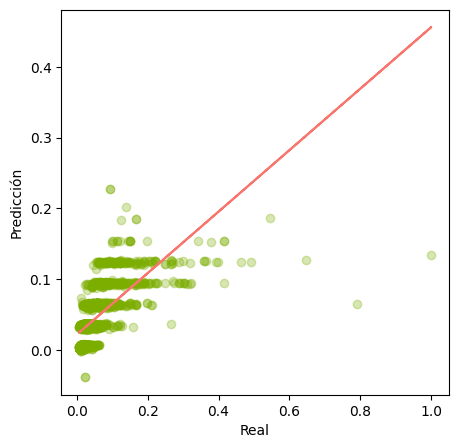

In [ ]:
# Graficamos valor real Vs predicho
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(x=y_train.values, y=yhat_Train1, c="#7CAE00", alpha=0.3)

# Agregamos línea de tendencia a graficar sobre los puntos
z = np.polyfit(y_train.values, yhat_Train1, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicción')
plt.xlabel('Real')

#### **Regresión con Red Neuronal Artificial (Multilayer Perceptron)**

In [ ]:
# Entrenamos el modelo
from sklearn.neural_network import MLPRegressor

# Segundo modelo
model2 = MLPRegressor()#solver='lbfgs', hidden_layer_sizes=(5), max_iter=500, activation = 'identity')
# Entrenamos
model2.fit(Train, y_train)
# Realizamos predicción
yhat_Train2 = model2.predict(Train)
# Calculamos el R2 score
r2train2 = r2_score(y_train, yhat_Train2)
# Calculamos el Mean Square Error (MSE)
MSEtrain2 = mean_squared_error(y_train, yhat_Train2)
# Evaluamos test
yhat_Test2 = model2.predict(Test)
# Calculamos el R2 score - Test
r2test2 = r2_score(y_test, yhat_Test2)
# Calculamos el Mean Square Error (MSE) - Test
MSEtest2 = mean_squared_error(y_test, yhat_Test2)
# Visualizamos
print('Red Neuronal')
print('Error R-squared - Train: ' + str(r2train2))
print('MSE - Train: ' + str(MSEtrain2))
print('Error R-squared - Test: ' + str(r2test2))
print('MSE - Test: ' + str(MSEtest2))

Red Neuronal
Error R-squared - Train: 0.4897013538834578
MSE - Train: 0.0009741726962585419
Error R-squared - Test: 0.44832236896554456
MSE - Test: 0.0013269722286227152


Graficamos las salidas de la **red neuronal** en el conjunto de **```Train```**

Text(0.5, 0, 'Real')

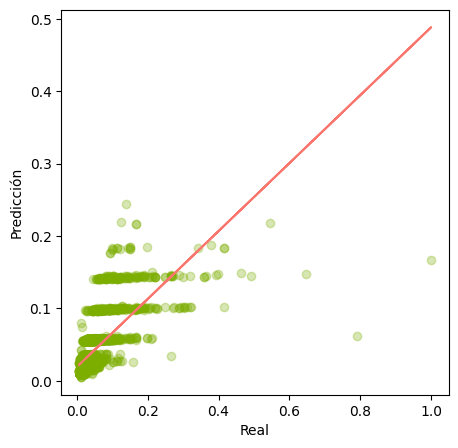

In [ ]:
# Graficamos valor real Vs predicho
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(x=y_train.values, y=yhat_Train2, c="#7CAE00", alpha=0.3)

# Agregamos línea de tendencia a graficar sobre los puntos
z = np.polyfit(y_train.values, yhat_Train2, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicción')
plt.xlabel('Real')

In [ ]:
y_train.size

5128

Text(0.5, 1.0, 'Test')

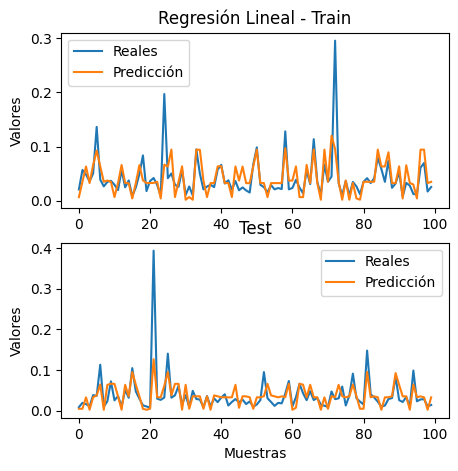

In [ ]:
plt.figure(figsize=(5,5))
plt.subplot(2,1,1)
plt.plot(y_train.values[:100])
plt.plot(yhat_Train1[:100])
plt.ylabel('Valores')
#plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Regresión Lineal - Train')
plt.subplot(2,1,2)
plt.plot(y_test.values[:100])
plt.plot(yhat_Test1[:100])
plt.ylabel('Valores')
plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Test')


Text(0.5, 1.0, 'Test')

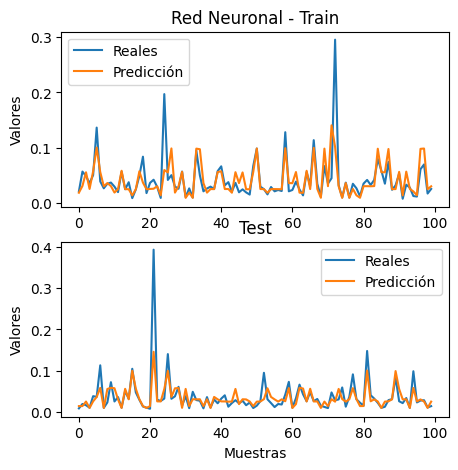

In [ ]:
plt.figure(figsize=(5,5))
plt.subplot(2,1,1)
plt.plot(y_train.values[:100])
plt.plot(yhat_Train2[:100])
plt.ylabel('Valores')
#plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Red Neuronal - Train')
plt.subplot(2,1,2)
plt.plot(y_test.values[:100])
plt.plot(yhat_Test2[:100])
plt.ylabel('Valores')
plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Test')

### ***k* Nearest Neighbors (kNN)**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model3= KNeighborsRegressor()
model3.fit(Train, y_train)
# Realizamos predicción
yhat_Train3 = model3.predict(Train)
# Calculamos el R2 score
r2train3 = r2_score(y_train, yhat_Train3)
# Calculamos el Mean Square Error (MSE)
MSEtrain3 = mean_squared_error(y_train, yhat_Train3)
# Evaluamos test
yhat_Test3 = model3.predict(Test)
# Calculamos el R2 score - Test
r2test3 = r2_score(y_test, yhat_Test3)
# Calculamos el Mean Square Error (MSE) - Test
MSEtest3 = mean_squared_error(y_test, yhat_Test3)
# Visualizamos
print('k-Neighbors')
print('Error R-squared - Train: ' + str(r2train3))
print('MSE - Train: ' + str(MSEtrain3))
print('Error R-squared - Test: ' + str(r2test3))
print('MSE - Test: ' + str(MSEtest3))

k-Neighbors
Error R-squared - Train: 0.7986695893184553
MSE - Train: 0.0003843447175591517
Error R-squared - Test: 0.7252205374083842
MSE - Test: 0.0006609380104305433


Text(0.5, 0, 'Real')

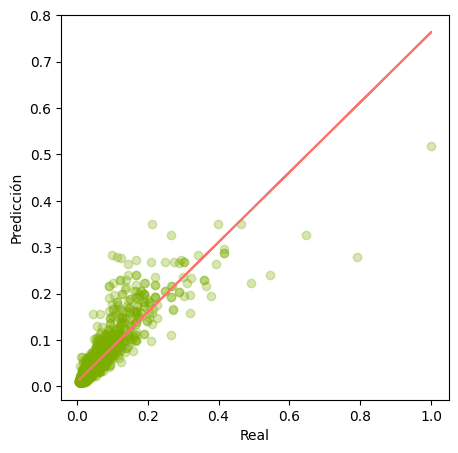

In [ ]:
# Graficamos valor real Vs predicho
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(x=y_train.values, y=yhat_Train3, c="#7CAE00", alpha=0.3)

# Agregamos línea de tendencia a graficar sobre los puntos
z = np.polyfit(y_train.values, yhat_Train3, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicción')
plt.xlabel('Real')

Text(0.5, 1.0, 'Test')

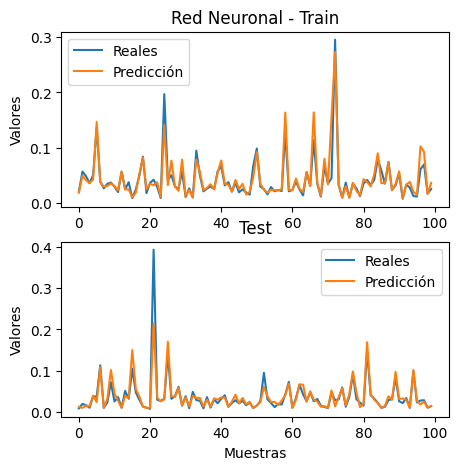

In [ ]:
plt.figure(figsize=(5,5))
plt.subplot(2,1,1)
plt.plot(y_train.values[:100])
plt.plot(yhat_Train3[:100])
plt.ylabel('Valores')
#plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Red Neuronal - Train')
plt.subplot(2,1,2)
plt.plot(y_test.values[:100])
plt.plot(yhat_Test3[:100])
plt.ylabel('Valores')
plt.xlabel('Muestras')
plt.legend(['Reales','Predicción'])
plt.title('Test')

**"Desplegando el Modelo"**

In [ ]:
# Predicciones

Habitaciones = 3
Banos = 2
Area = 100

Salida = model3.predict([[Habitaciones/M_H,Banos/M_B,Area/M_A]])
Salida*M_V
# Visualizamos

print('Valor estimado: ' + str(Salida*M_V))

Valor estimado: [5.239e+08]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [ ]:
pd.DataFrame(np.array([[r2train1,r2train2,r2train3],[r2test1,r2test2,r2test3],[MSEtrain1,MSEtrain2,MSEtrain3],[MSEtest1,MSEtest2,MSEtest3]]),
             index=['R2 Train', 'R2 Test','MSE Train','MSE Test'],
             columns=['Regresión Lineal','Red Neuronal', 'kNN'])

,Regresión Lineal,Red Neuronal,kNN
R2 Train,0.433835,0.489701,0.798670
R2 Test,0.400923,0.448322,0.725221
MSE Train,0.001081,0.000974,0.000384
MSE Test,0.001441,0.001327,0.000661
